# 演示工具和LLM的交互方式

## 新知识点
- tools_condition：langraph预置的条件边函数，固定返回['tools',END]
- ToolMessage/HumanMessage/AIMessage/SystemMessage： langchain预置的消息类型
- ToolNode：langgraph预置函数，tool函数只需要关注计算过程，由ToolNode来决策函数的调用以及message的包装

## 要求
- 必须使用langchain的消息类型进行交互
- 必须使用tools_condition条件边函数
- llm节点作为router，需要能够决策走tools分支还是END

### 实现步骤
- 创建llm client并绑定工具
- 创建router节点/tools节点
- 创建并编译图，打印其结构
- 测试图

In [1]:

# 通用步骤
from langchain_openai import ChatOpenAI


glm_client = ChatOpenAI(
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",
    model="glm-4.7",
)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# 绑定工具
from langchain.messages import ToolMessage


# 工具函数
def multipy(a: int, b: int) -> int:
    """计算 a 和 b 的乘积"""
    return a * b

glm_client_with_tool = glm_client.bind_tools([multipy])

In [3]:
# 创建router节点
from langgraph.graph import MessagesState


def router_node(state: MessagesState):
    return {"messages": [glm_client_with_tool.invoke(state["messages"])]}

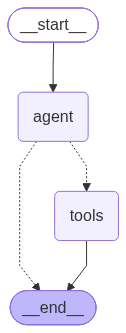

In [4]:
# 创建图
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


graph = StateGraph(MessagesState)
graph.add_node("agent",router_node)
graph.add_node("tools", ToolNode([multipy]))

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools",END) # tools可以直接END，也可以回到agent实现循环，在多个tool的场景下循环比较常见

app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
from langchain.messages import HumanMessage


res = app.invoke({"messages":[HumanMessage(content="5乘以18 等于多少？")]})

In [6]:
for msg in res["messages"]:
    msg.pretty_print()
    # print(msg.model_dump_json(indent=2))

================================ Human Message =================================

5乘以18 等于多少？
================================== Ai Message ==================================

我来帮您计算5乘以18的结果。
Tool Calls:
  multipy (call_-7347647531066581079)
 Call ID: call_-7347647531066581079
  Args:
    a: 5
    b: 18
================================= Tool Message =================================
Name: multipy

90


In [7]:
res = app.invoke({"messages":[HumanMessage(content='你好，介绍下langchain？')]})
for msg in res["messages"]:
    # print(msg.model_dump_json(indent = 2))
    msg.pretty_print()

================================ Human Message =================================

你好，介绍下langchain？
================================== Ai Message ==================================

你好！很高兴为你介绍 **LangChain**。

## 什么是 LangChain？

LangChain 是一个开源的 Python 和 JavaScript 框架，专门用于构建基于大语言模型（LLM）的应用程序。它提供了丰富的工具和组件，帮助开发者更轻松地集成和扩展 LLM 的能力。

## 核心特性

### 1. **模块化架构**
- **Models**: 支持多种 LLM（如 GPT-4、Claude、Llama 等）和嵌入模型
- **Prompts**: 提供提示词模板管理和优化
- **Memory**: 实现对话历史存储和检索
- **Indexes**: 文档索引和检索功能
- **Chains**: 将多个组件串联成复杂的工作流
- **Agents**: 让 LLM 能够自主决策和使用工具

### 2. **丰富的集成**
- 支持 OpenAI、Anthropic、Hugging Face 等多种模型提供商
- 集成向量数据库（如 Pinecone、Chroma、FAISS）
- 连接外部 API 和工具
- 支持多种数据源（PDF、网页、数据库等）

### 3. **开发者友好**
- 清晰的 API 设计
- 详细的文档和示例
- 活跃的社区支持
- 持续更新和维护

## 典型应用场景

### 1. **问答系统**
- 基于文档的智能问答
- RAG（检索增强生成）应用

### 2. **聊天机器人**
- 具有记忆能力的对话助手
- 多轮对话管理

### 3. **智能代理**
- 自动化任务执行
- 工具调用和决策

### 4. **内容生成**
- 文档写作辅助
- 代码生成
- 创意写作

## 基本使用示例

```python
from langchain.llms import OpenAI
from langchain.chains impo